# V2 Tweet Generation — Statistical Analysis
Generates a large sample of tweets across all VIX×EPU×topic combinations,
saves to CSV, then runs sentiment and keyword analysis.

**Run once to generate** — subsequent runs load from CSV and skip generation.

In [1]:
import os, json, torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from transformers import GPT2LMHeadModel, GPT2Tokenizer

try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'vaderSentiment', '-q'])
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

try:
    import statsmodels.formula.api as smf
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'statsmodels', '-q'])
    import statsmodels.formula.api as smf

print('Imports ready.')

/Users/school/miniconda3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports ready.


In [2]:
MODEL_DIR    = 'booth_results_v2/models/trump_gpt2_v2'
CUTOFFS_PATH = 'booth_results_v2/results/bucket_cutoffs_v2.json'

tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
with open(os.path.join(MODEL_DIR, 'tokenizer_config.json')) as f:
    tcfg = json.load(f)
tokenizer.add_special_tokens({'additional_special_tokens': tcfg.get('extra_special_tokens', [])})
tokenizer.pad_token = tokenizer.eos_token

model = GPT2LMHeadModel.from_pretrained(MODEL_DIR)
model.eval()

device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else 'cpu'
)
model.to(device)
print(f'Model loaded on {device}')

with open(CUTOFFS_PATH) as f:
    cutoffs = json.load(f)

VIX_LABELS = ['VIX_VERY_LOW', 'VIX_LOW', 'VIX_MED', 'VIX_HIGH', 'VIX_VERY_HIGH']
EPU_LABELS = ['EPU_VERY_LOW', 'EPU_LOW', 'EPU_MED', 'EPU_HIGH', 'EPU_VERY_HIGH']
TOPICS     = [0, 1, 2, 3, 4, 5]
TOPIC_NAMES = {
    0: 'Fake News & Witch Hunt',
    1: 'Crooked Democrats',
    2: 'America First',
    3: 'MAGA Endorsements',
    4: 'Make America Great Again',
    5: 'Rallies & Events',
}

/Users/school/miniconda3/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Model loaded on mps


---
## Generation
Set `N_PER_COMBO` below. 10 gives 1,500 tweets (~15 min on MPS). Increase for more statistical power.

In [3]:
N_PER_COMBO = 10   # tweets per VIX x EPU x topic combination
CSV_PATH    = 'generated_analysis_v2.csv'

total = len(VIX_LABELS) * len(EPU_LABELS) * len(TOPICS) * N_PER_COMBO
print(f'N_PER_COMBO = {N_PER_COMBO}')
print(f'Total tweets to generate: {total}')
print(f'Per VIX bucket: {total // len(VIX_LABELS)}')
print(f'Per (topic, VIX) cell: {N_PER_COMBO * len(EPU_LABELS)}')

N_PER_COMBO = 10
Total tweets to generate: 1500
Per VIX bucket: 300
Per (topic, VIX) cell: 50


In [4]:
def generate_tweet(vix_label, epu_label, topic_id,
                   max_new_tokens=90, temperature=0.85, top_p=0.92):
    prompt    = f'[{vix_label}] [{epu_label}] [TOPIC_{topic_id}]'
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)
    prompt_len = input_ids.shape[1]
    with torch.no_grad():
        output = model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=top_p,
            no_repeat_ngram_size=3,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(output[0][prompt_len:], skip_special_tokens=True).strip()

if os.path.exists(CSV_PATH):
    print(f'{CSV_PATH} already exists — skipping generation.')
    print('Delete the file and re-run this cell to regenerate.')
else:
    rows = []
    done = 0
    for vi, vl in enumerate(VIX_LABELS):
        for ei, el in enumerate(EPU_LABELS):
            for t in TOPICS:
                for _ in range(N_PER_COMBO):
                    text = generate_tweet(vl, el, t)
                    rows.append({
                        'vix_label':  vl,
                        'epu_label':  el,
                        'vix_rank':   vi,
                        'epu_rank':   ei,
                        'topic_id':   t,
                        'topic_name': TOPIC_NAMES[t],
                        'text':       text,
                    })
                    done += 1
            print(f'  [{vl}] [{el}] done  ({done}/{total})')
    pd.DataFrame(rows).to_csv(CSV_PATH, index=False)
    print(f'\nSaved {len(rows)} tweets to {CSV_PATH}')

  [VIX_VERY_LOW] [EPU_VERY_LOW] done  (60/1500)
  [VIX_VERY_LOW] [EPU_LOW] done  (120/1500)
  [VIX_VERY_LOW] [EPU_MED] done  (180/1500)
  [VIX_VERY_LOW] [EPU_HIGH] done  (240/1500)
  [VIX_VERY_LOW] [EPU_VERY_HIGH] done  (300/1500)
  [VIX_LOW] [EPU_VERY_LOW] done  (360/1500)
  [VIX_LOW] [EPU_LOW] done  (420/1500)
  [VIX_LOW] [EPU_MED] done  (480/1500)
  [VIX_LOW] [EPU_HIGH] done  (540/1500)
  [VIX_LOW] [EPU_VERY_HIGH] done  (600/1500)
  [VIX_MED] [EPU_VERY_LOW] done  (660/1500)
  [VIX_MED] [EPU_LOW] done  (720/1500)
  [VIX_MED] [EPU_MED] done  (780/1500)
  [VIX_MED] [EPU_HIGH] done  (840/1500)
  [VIX_MED] [EPU_VERY_HIGH] done  (900/1500)
  [VIX_HIGH] [EPU_VERY_LOW] done  (960/1500)
  [VIX_HIGH] [EPU_LOW] done  (1020/1500)
  [VIX_HIGH] [EPU_MED] done  (1080/1500)
  [VIX_HIGH] [EPU_HIGH] done  (1140/1500)
  [VIX_HIGH] [EPU_VERY_HIGH] done  (1200/1500)
  [VIX_VERY_HIGH] [EPU_VERY_LOW] done  (1260/1500)
  [VIX_VERY_HIGH] [EPU_LOW] done  (1320/1500)
  [VIX_VERY_HIGH] [EPU_MED] done  (1380/15

---
## Load CSV + VADER Scoring
Run from here if CSV already exists.

In [5]:
df  = pd.read_csv(CSV_PATH)
sia = SentimentIntensityAnalyzer()

scores        = df['text'].apply(lambda t: sia.polarity_scores(str(t)))
df['compound'] = scores.apply(lambda s: s['compound'])
df['pos']      = scores.apply(lambda s: s['pos'])
df['neg']      = scores.apply(lambda s: s['neg'])
df['neu']      = scores.apply(lambda s: s['neu'])

print(f'Loaded {len(df)} tweets')
print(f'\nMean compound by VIX bucket:')
print(df.groupby('vix_label')['compound'].agg(['mean','std','count']).round(3))

Loaded 1500 tweets

Mean compound by VIX bucket:
                mean    std  count
vix_label                         
VIX_HIGH       0.451  0.654    300
VIX_LOW        0.385  0.683    300
VIX_MED        0.409  0.679    300
VIX_VERY_HIGH  0.403  0.698    300
VIX_VERY_LOW   0.393  0.689    300


---
## Sentiment by VIX Bucket

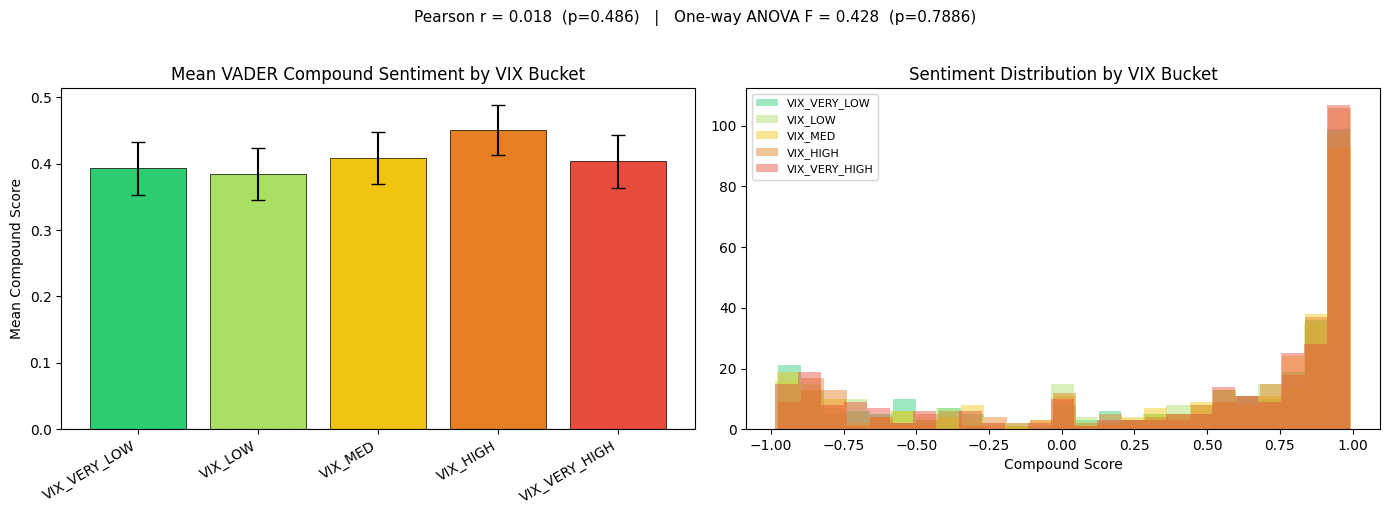

Pearson r = 0.0180,  p = 0.4862
One-way ANOVA: F = 0.4278,  p = 0.7886


In [6]:
colors = ['#2ecc71', '#a8e063', '#f1c40f', '#e67e22', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart with error bars
means = [df[df['vix_rank'] == i]['compound'].mean() for i in range(5)]
sems  = [df[df['vix_rank'] == i]['compound'].sem()  for i in range(5)]
axes[0].bar(VIX_LABELS, means, yerr=sems, color=colors, capsize=5, edgecolor='black', linewidth=0.5)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Mean VADER Compound Sentiment by VIX Bucket')
axes[0].set_ylabel('Mean Compound Score')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

# Distribution overlay
for vi, vl in enumerate(VIX_LABELS):
    subset = df[df['vix_rank'] == vi]['compound']
    axes[1].hist(subset, bins=25, alpha=0.45, label=vl, color=colors[vi])
axes[1].set_title('Sentiment Distribution by VIX Bucket')
axes[1].set_xlabel('Compound Score')
axes[1].legend(fontsize=8)

# Stats
r, p_r = stats.pearsonr(df['vix_rank'], df['compound'])
groups = [df[df['vix_rank'] == i]['compound'].values for i in range(5)]
f_stat, p_anova = stats.f_oneway(*groups)

fig.suptitle(
    f'Pearson r = {r:.3f}  (p={p_r:.3f})   |   One-way ANOVA F = {f_stat:.3f}  (p={p_anova:.4f})',
    y=1.02, fontsize=11
)
plt.tight_layout()
plt.savefig('analysis_vix_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Pearson r = {r:.4f},  p = {p_r:.4f}')
print(f'One-way ANOVA: F = {f_stat:.4f},  p = {p_anova:.4f}')

---
## Sentiment by EPU Bucket

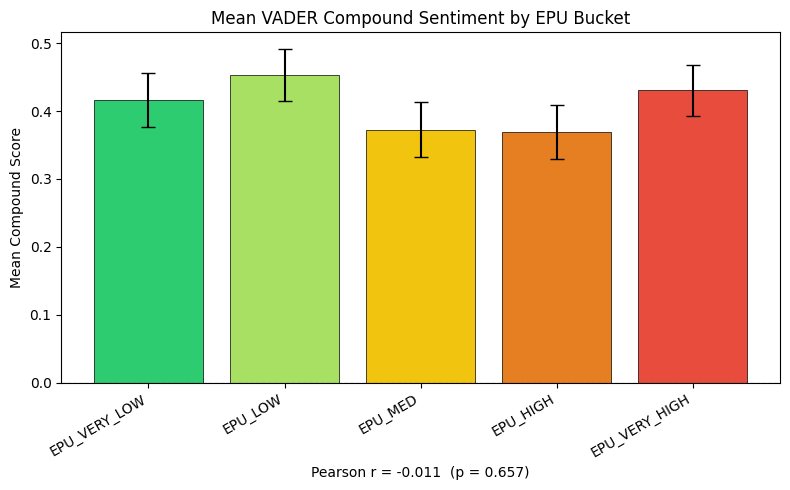

Pearson r(EPU rank, sentiment) = -0.0115,  p = 0.6568


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

means = [df[df['epu_rank'] == i]['compound'].mean() for i in range(5)]
sems  = [df[df['epu_rank'] == i]['compound'].sem()  for i in range(5)]
ax.bar(EPU_LABELS, means, yerr=sems, color=colors, capsize=5, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Mean VADER Compound Sentiment by EPU Bucket')
ax.set_ylabel('Mean Compound Score')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

r_epu, p_epu = stats.pearsonr(df['epu_rank'], df['compound'])
ax.set_xlabel(f'Pearson r = {r_epu:.3f}  (p = {p_epu:.3f})')
plt.tight_layout()
plt.savefig('analysis_epu_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Pearson r(EPU rank, sentiment) = {r_epu:.4f},  p = {p_epu:.4f}')

---
## VIX × EPU Sentiment Heatmap

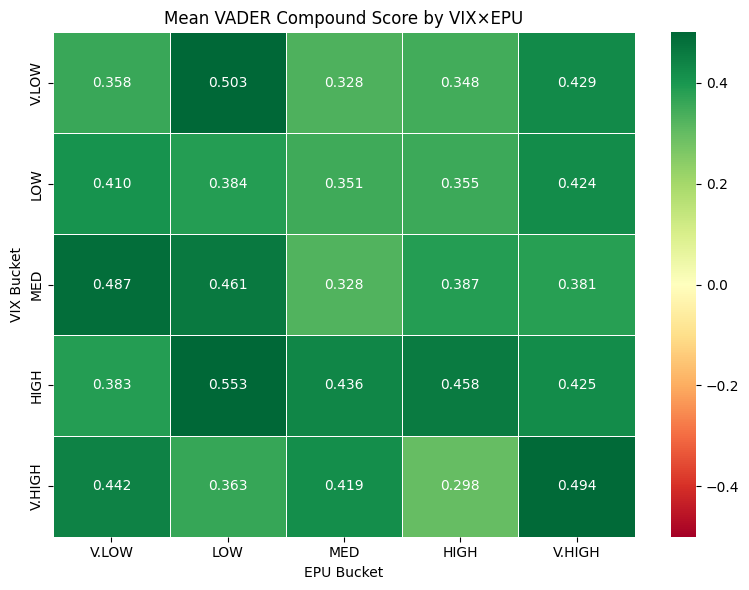

In [8]:
pivot = df.groupby(['vix_rank', 'epu_rank'])['compound'].mean().unstack()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pivot,
    xticklabels=['V.LOW', 'LOW', 'MED', 'HIGH', 'V.HIGH'],
    yticklabels=['V.LOW', 'LOW', 'MED', 'HIGH', 'V.HIGH'],
    annot=True, fmt='.3f',
    cmap='RdYlGn', center=0, vmin=-0.5, vmax=0.5,
    linewidths=0.5, ax=ax
)
ax.set_xlabel('EPU Bucket')
ax.set_ylabel('VIX Bucket')
ax.set_title('Mean VADER Compound Score by VIX×EPU')
plt.tight_layout()
plt.savefig('analysis_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Keyword Frequency by VIX Bucket

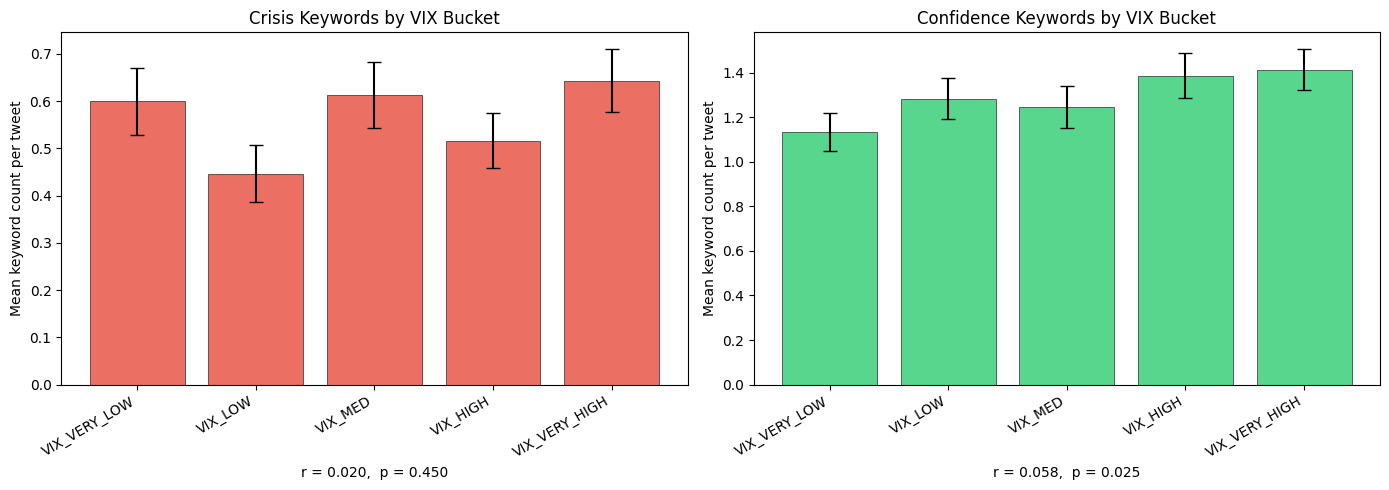

In [9]:
CRISIS_WORDS = [
    'witch hunt', 'fake', 'hoax', 'corrupt', 'radical',
    'rigged', 'stolen', 'disgrace', 'disaster', 'enemy',
    'scam', 'fraud', 'weaponiz', 'impeach'
]
CONFIDENCE_WORDS = [
    'great', 'win', 'tremendous', 'fantastic', 'incredible',
    'winning', 'best', 'strong', 'beautiful', 'perfect',
    'congratulations', 'honor'
]

def kw_count(text, words):
    t = str(text).lower()
    return sum(t.count(w) for w in words)

df['crisis_n']     = df['text'].apply(lambda t: kw_count(t, CRISIS_WORDS))
df['confidence_n'] = df['text'].apply(lambda t: kw_count(t, CONFIDENCE_WORDS))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title, color in [
    (axes[0], 'crisis_n',     'Crisis Keywords by VIX Bucket',     '#e74c3c'),
    (axes[1], 'confidence_n', 'Confidence Keywords by VIX Bucket', '#2ecc71'),
]:
    means = [df[df['vix_rank'] == i][col].mean() for i in range(5)]
    sems  = [df[df['vix_rank'] == i][col].sem()  for i in range(5)]
    ax.bar(VIX_LABELS, means, yerr=sems, color=color, alpha=0.8, capsize=5,
           edgecolor='black', linewidth=0.5)
    ax.set_title(title)
    ax.set_ylabel('Mean keyword count per tweet')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    r_kw, p_kw = stats.pearsonr(df['vix_rank'], df[col])
    ax.set_xlabel(f'r = {r_kw:.3f},  p = {p_kw:.3f}')

plt.tight_layout()
plt.savefig('analysis_keywords.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sentiment by VIX Bucket, Faceted by Topic
Shows whether VIX conditioning affects some topics more than others.

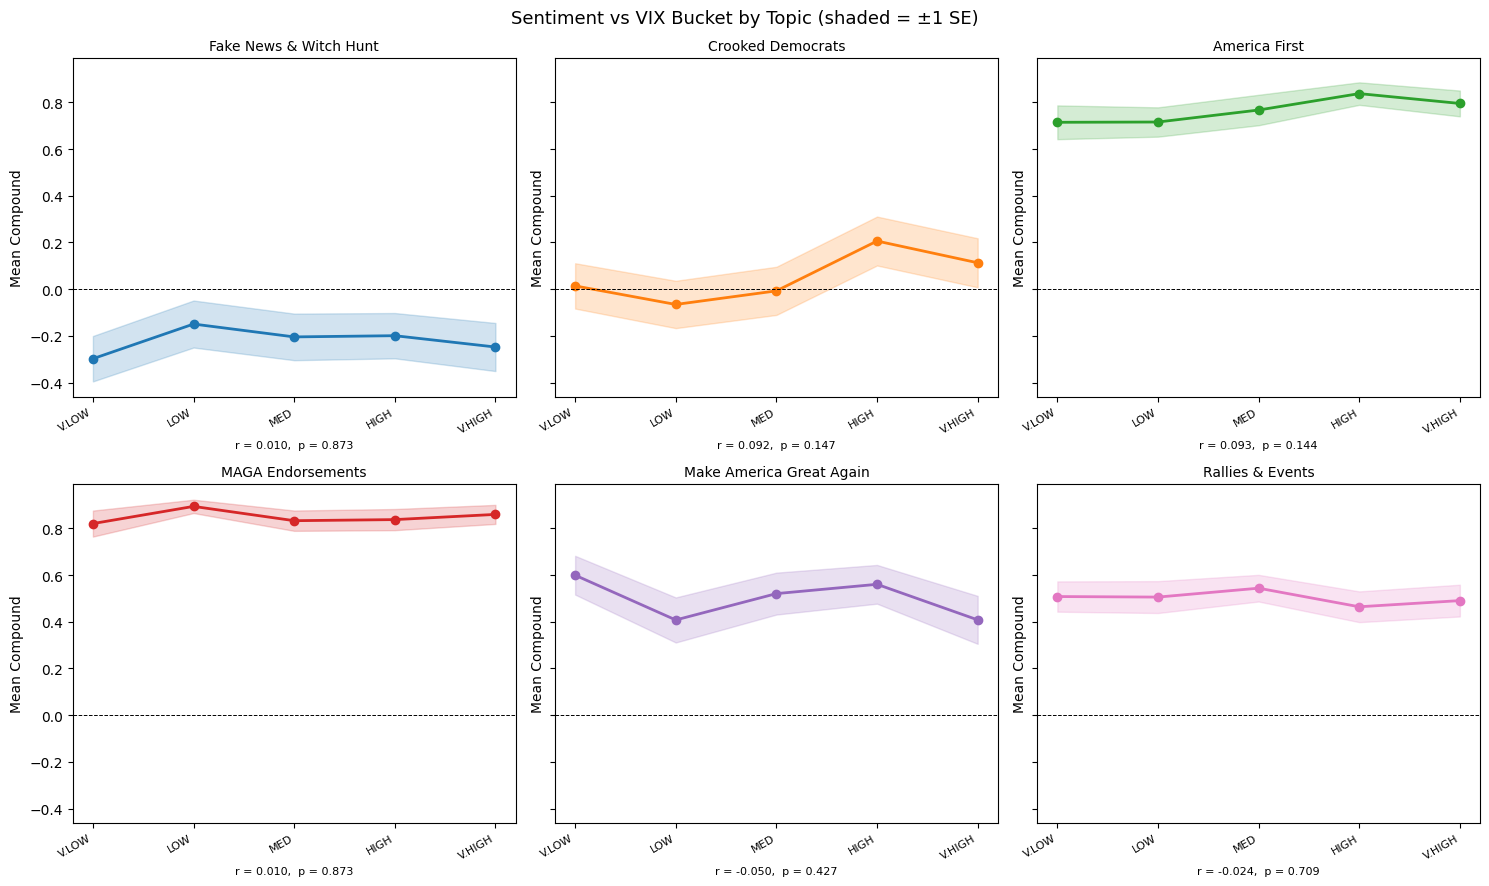

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=True)
axes = axes.flatten()
topic_colors = plt.cm.tab10(np.linspace(0, 0.6, 6))

for t in TOPICS:
    ax = axes[t]
    sub = df[df['topic_id'] == t]
    means = [sub[sub['vix_rank'] == i]['compound'].mean() for i in range(5)]
    sems  = [sub[sub['vix_rank'] == i]['compound'].sem()  for i in range(5)]
    ax.plot(range(5), means, marker='o', color=topic_colors[t], linewidth=2)
    ax.fill_between(
        range(5),
        [m - s for m, s in zip(means, sems)],
        [m + s for m, s in zip(means, sems)],
        alpha=0.2, color=topic_colors[t]
    )
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_xticks(range(5))
    ax.set_xticklabels(['V.LOW','LOW','MED','HIGH','V.HIGH'], rotation=30, ha='right', fontsize=8)
    ax.set_title(TOPIC_NAMES[t], fontsize=10)
    ax.set_ylabel('Mean Compound')
    r_t, p_t = stats.pearsonr(
        sub['vix_rank'], sub['compound']
    )
    ax.set_xlabel(f'r = {r_t:.3f},  p = {p_t:.3f}', fontsize=8)

fig.suptitle('Sentiment vs VIX Bucket by Topic (shaded = ±1 SE)', fontsize=13)
plt.tight_layout()
plt.savefig('analysis_topic_vix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## OLS Regression: Sentiment ~ VIX + EPU + Topic
Controls for topic to isolate the independent effect of VIX and EPU on sentiment.

In [11]:
result = smf.ols('compound ~ vix_rank + epu_rank + C(topic_id)', data=df).fit()
print(result.summary())
print('\n--- Key coefficients ---')
print(f'vix_rank:  coef = {result.params["vix_rank"]:.4f},  p = {result.pvalues["vix_rank"]:.4f}')
print(f'epu_rank:  coef = {result.params["epu_rank"]:.4f},  p = {result.pvalues["epu_rank"]:.4f}')
print(f'R² = {result.rsquared:.4f}')

                            OLS Regression Results                            
Dep. Variable:               compound   R-squared:                       0.311
Model:                            OLS   Adj. R-squared:                  0.308
Method:                 Least Squares   F-statistic:                     96.11
Date:                Mon, 25 May 2026   Prob (F-statistic):          6.49e-116
Time:                        17:36:52   Log-Likelihood:                -1270.8
No. Observations:                1500   AIC:                             2558.
Df Residuals:                    1492   BIC:                             2600.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -0.2260      0.046  

---
## Real Tweet Comparison
Run the same VADER + keyword analysis on the actual training tweets (`tweet_labels_v2.csv`) so we can compare generated vs. real statistics.

In [12]:
REAL_CSV = 'tweet_labels_v2.csv'

real = pd.read_csv(REAL_CSV)

# Align column names to match generated df
VIX_RANK_MAP = {l: i for i, l in enumerate(VIX_LABELS)}
EPU_RANK_MAP = {l: i for i, l in enumerate(EPU_LABELS)}

real = real.rename(columns={
    'vix_bucket':   'vix_label',
    'epu_bucket':   'epu_label',
    'lda_topic':    'topic_id',
})
real['vix_rank']   = real['vix_label'].map(VIX_RANK_MAP)
real['epu_rank']   = real['epu_label'].map(EPU_RANK_MAP)
real['topic_name'] = real['topic_id'].map(TOPIC_NAMES)

# Drop rows where bucket mapping failed (shouldn't happen)
real = real.dropna(subset=['vix_rank', 'epu_rank'])
real['vix_rank'] = real['vix_rank'].astype(int)
real['epu_rank'] = real['epu_rank'].astype(int)

# VADER scores
r_scores         = real['text'].apply(lambda t: sia.polarity_scores(str(t)))
real['compound'] = r_scores.apply(lambda s: s['compound'])
real['pos']      = r_scores.apply(lambda s: s['pos'])
real['neg']      = r_scores.apply(lambda s: s['neg'])

# Keyword counts
real['crisis_n']     = real['text'].apply(lambda t: kw_count(t, CRISIS_WORDS))
real['confidence_n'] = real['text'].apply(lambda t: kw_count(t, CONFIDENCE_WORDS))

print(f'Real tweets loaded: {len(real)}')
print(f'\nMean compound by VIX bucket (real):')
print(real.groupby('vix_label')['compound'].agg(['mean','std','count']).round(3))

Real tweets loaded: 26627

Mean compound by VIX bucket (real):
                mean    std  count
vix_label                         
VIX_HIGH       0.169  0.672   5430
VIX_LOW        0.171  0.656   5700
VIX_MED        0.217  0.660   5217
VIX_VERY_HIGH  0.176  0.642   5588
VIX_VERY_LOW   0.169  0.624   4692


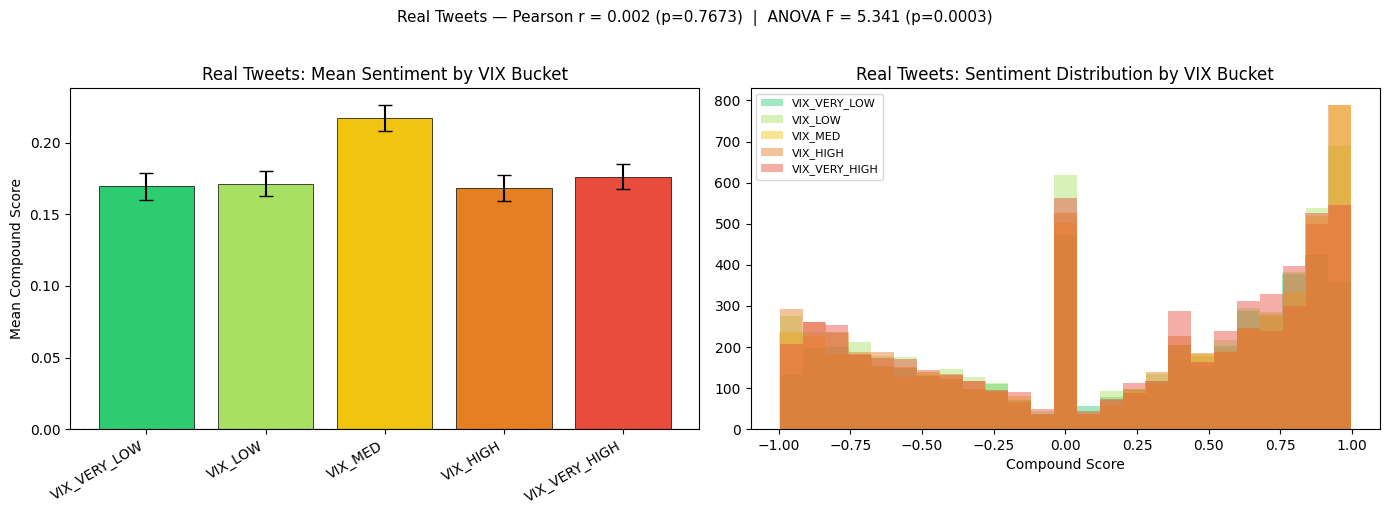

Real tweets — Pearson r = 0.0018,  p = 0.7673
Real tweets — ANOVA F = 5.3412,  p = 0.0003


In [13]:
# Sentiment by VIX — real tweets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

means_r = [real[real['vix_rank'] == i]['compound'].mean() for i in range(5)]
sems_r  = [real[real['vix_rank'] == i]['compound'].sem()  for i in range(5)]
axes[0].bar(VIX_LABELS, means_r, yerr=sems_r, color=colors, capsize=5,
            edgecolor='black', linewidth=0.5)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Real Tweets: Mean Sentiment by VIX Bucket')
axes[0].set_ylabel('Mean Compound Score')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

for vi, vl in enumerate(VIX_LABELS):
    subset = real[real['vix_rank'] == vi]['compound']
    axes[1].hist(subset, bins=25, alpha=0.45, label=vl, color=colors[vi])
axes[1].set_title('Real Tweets: Sentiment Distribution by VIX Bucket')
axes[1].set_xlabel('Compound Score')
axes[1].legend(fontsize=8)

r_real, p_real = stats.pearsonr(real['vix_rank'], real['compound'])
groups_r = [real[real['vix_rank'] == i]['compound'].values for i in range(5)]
f_real, p_anova_real = stats.f_oneway(*groups_r)

fig.suptitle(
    f'Real Tweets — Pearson r = {r_real:.3f} (p={p_real:.4f})  |  ANOVA F = {f_real:.3f} (p={p_anova_real:.4f})',
    y=1.02, fontsize=11
)
plt.tight_layout()
plt.savefig('real_vix_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Real tweets — Pearson r = {r_real:.4f},  p = {p_real:.4f}')
print(f'Real tweets — ANOVA F = {f_real:.4f},  p = {p_anova_real:.4f}')

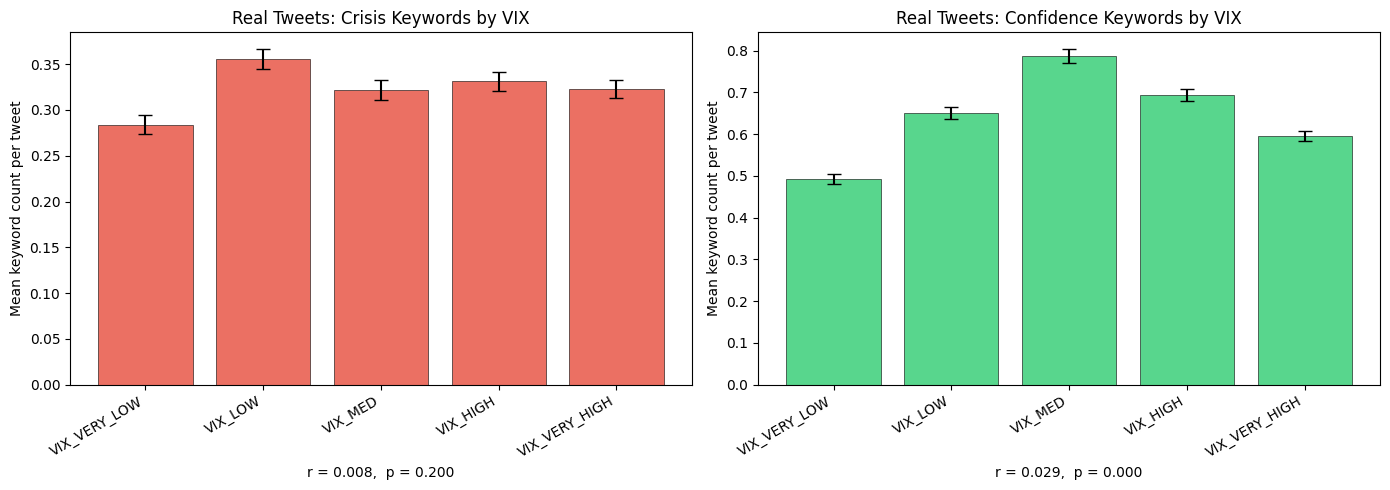

In [14]:
# Keywords by VIX — real tweets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title, color in [
    (axes[0], 'crisis_n',     'Real Tweets: Crisis Keywords by VIX',     '#e74c3c'),
    (axes[1], 'confidence_n', 'Real Tweets: Confidence Keywords by VIX', '#2ecc71'),
]:
    means = [real[real['vix_rank'] == i][col].mean() for i in range(5)]
    sems  = [real[real['vix_rank'] == i][col].sem()  for i in range(5)]
    ax.bar(VIX_LABELS, means, yerr=sems, color=color, alpha=0.8, capsize=5,
           edgecolor='black', linewidth=0.5)
    ax.set_title(title)
    ax.set_ylabel('Mean keyword count per tweet')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    r_kw, p_kw = stats.pearsonr(real['vix_rank'], real[col])
    ax.set_xlabel(f'r = {r_kw:.3f},  p = {p_kw:.3f}')

plt.tight_layout()
plt.savefig('real_keywords.png', dpi=150, bbox_inches='tight')
plt.show()

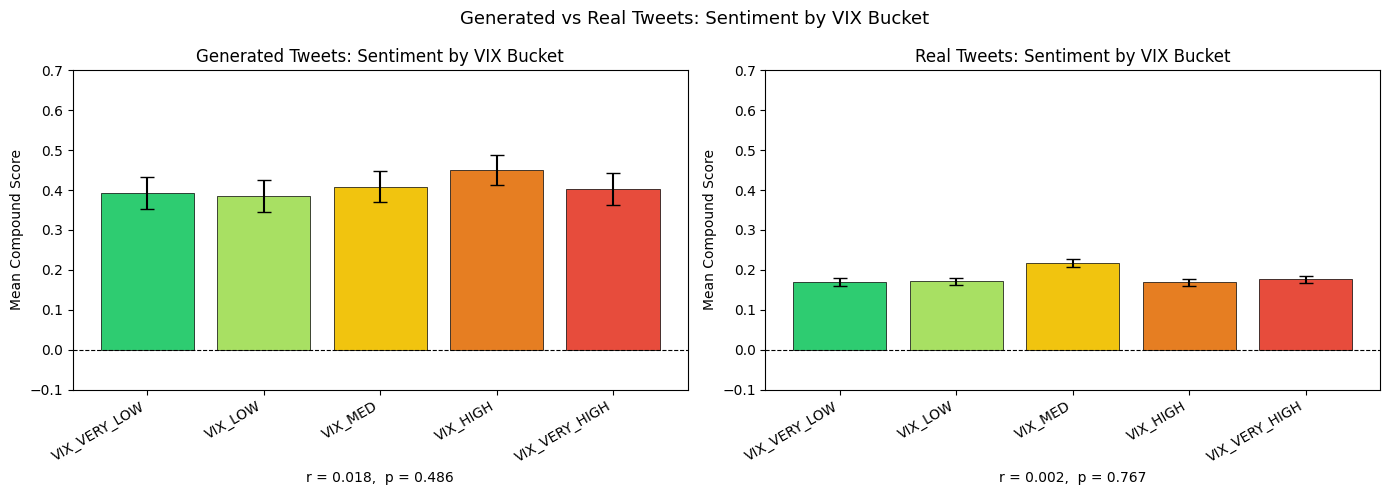

In [15]:
# Side-by-side: generated vs real sentiment by VIX
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, source_df, title in [
    (axes[0], df,   'Generated Tweets'),
    (axes[1], real, 'Real Tweets'),
]:
    means = [source_df[source_df['vix_rank'] == i]['compound'].mean() for i in range(5)]
    sems  = [source_df[source_df['vix_rank'] == i]['compound'].sem()  for i in range(5)]
    ax.bar(VIX_LABELS, means, yerr=sems, color=colors, capsize=5,
           edgecolor='black', linewidth=0.5)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'{title}: Sentiment by VIX Bucket')
    ax.set_ylabel('Mean Compound Score')
    ax.set_ylim(-0.1, 0.7)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    r_s, p_s = stats.pearsonr(source_df['vix_rank'], source_df['compound'])
    ax.set_xlabel(f'r = {r_s:.3f},  p = {p_s:.3f}')

fig.suptitle('Generated vs Real Tweets: Sentiment by VIX Bucket', fontsize=13)
plt.tight_layout()
plt.savefig('comparison_vix_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# OLS on real tweets — same spec as generated
result_real = smf.ols('compound ~ vix_rank + epu_rank + C(topic_id)', data=real).fit()
print('=== OLS: Real Tweets ===')
print(f'vix_rank:  coef = {result_real.params["vix_rank"]:.4f},  p = {result_real.pvalues["vix_rank"]:.4f}')
print(f'epu_rank:  coef = {result_real.params["epu_rank"]:.4f},  p = {result_real.pvalues["epu_rank"]:.4f}')
print(f'R² = {result_real.rsquared:.4f}')
print()
print('=== OLS: Generated Tweets (for comparison) ===')
print(f'vix_rank:  coef = {result.params["vix_rank"]:.4f},  p = {result.pvalues["vix_rank"]:.4f}')
print(f'epu_rank:  coef = {result.params["epu_rank"]:.4f},  p = {result.pvalues["epu_rank"]:.4f}')
print(f'R² = {result.rsquared:.4f}')

=== OLS: Real Tweets ===
vix_rank:  coef = -0.0144,  p = 0.0000
epu_rank:  coef = 0.0229,  p = 0.0000
R² = 0.2319

=== OLS: Generated Tweets (for comparison) ===
vix_rank:  coef = 0.0087,  p = 0.4026
epu_rank:  coef = -0.0055,  p = 0.5933
R² = 0.3108
